[INFO] Using device: cuda
[INFO] Loading CIFAR-10 pretrained model from RobustBench …


Downloading...
From (original): https://drive.google.com/uc?id=1t98aEuzeTL8P7Kpd5DIrCoCL21BNZUhC
From (redirected): https://drive.google.com/uc?id=1t98aEuzeTL8P7Kpd5DIrCoCL21BNZUhC&confirm=t&uuid=c602e274-3b49-4247-8441-5d97b17916e1
To: /content/models/cifar10/corruptions/Standard.pt
100%|██████████| 292M/292M [00:02<00:00, 135MB/s]


[INFO] Model loaded: Standard

EXPERIMENTS 1–3: Source | Norm | Tent  (CIFAR-10-C, severity=5)

[Source]
Starting download from https://zenodo.org/api/records/2535967/files/CIFAR-10-C.tar/content


44533it [03:05, 239.80it/s]                           


Download finished, extracting...
Downloaded and extracted.
  gaussian_noise             acc=27.10%  err=72.90%
  shot_noise                 acc=35.30%  err=64.70%
  impulse_noise              acc=28.10%  err=71.90%
  defocus_blur               acc=51.30%  err=48.70%
  glass_blur                 acc=46.10%  err=53.90%
  motion_blur                acc=63.90%  err=36.10%
  zoom_blur                  acc=58.90%  err=41.10%
  snow                       acc=75.10%  err=24.90%
  frost                      acc=59.40%  err=40.60%
  fog                        acc=74.40%  err=25.60%
  brightness                 acc=90.00%  err=10.00%
  contrast                   acc=51.10%  err=48.90%
  elastic_transform          acc=74.70%  err=25.30%
  pixelate                   acc=42.40%  err=57.60%
  jpeg_compression           acc=70.20%  err=29.80%

[Norm]
  gaussian_noise             acc=72.30%  err=27.70%
  shot_noise                 acc=73.40%  err=26.60%
  impulse_noise              acc=61.90%  err=38.1

100%|██████████| 97.8M/97.8M [00:00<00:00, 198MB/s]


[INFO] ImageNet model loaded: Standard_R50

[Source]
[WARN] ImageNet-C skipped: [Errno 2] No such file or directory: 'data/ImageNet-C/gaussian_noise/5'

[VIZ] Showing sample corrupted CIFAR-10 images …


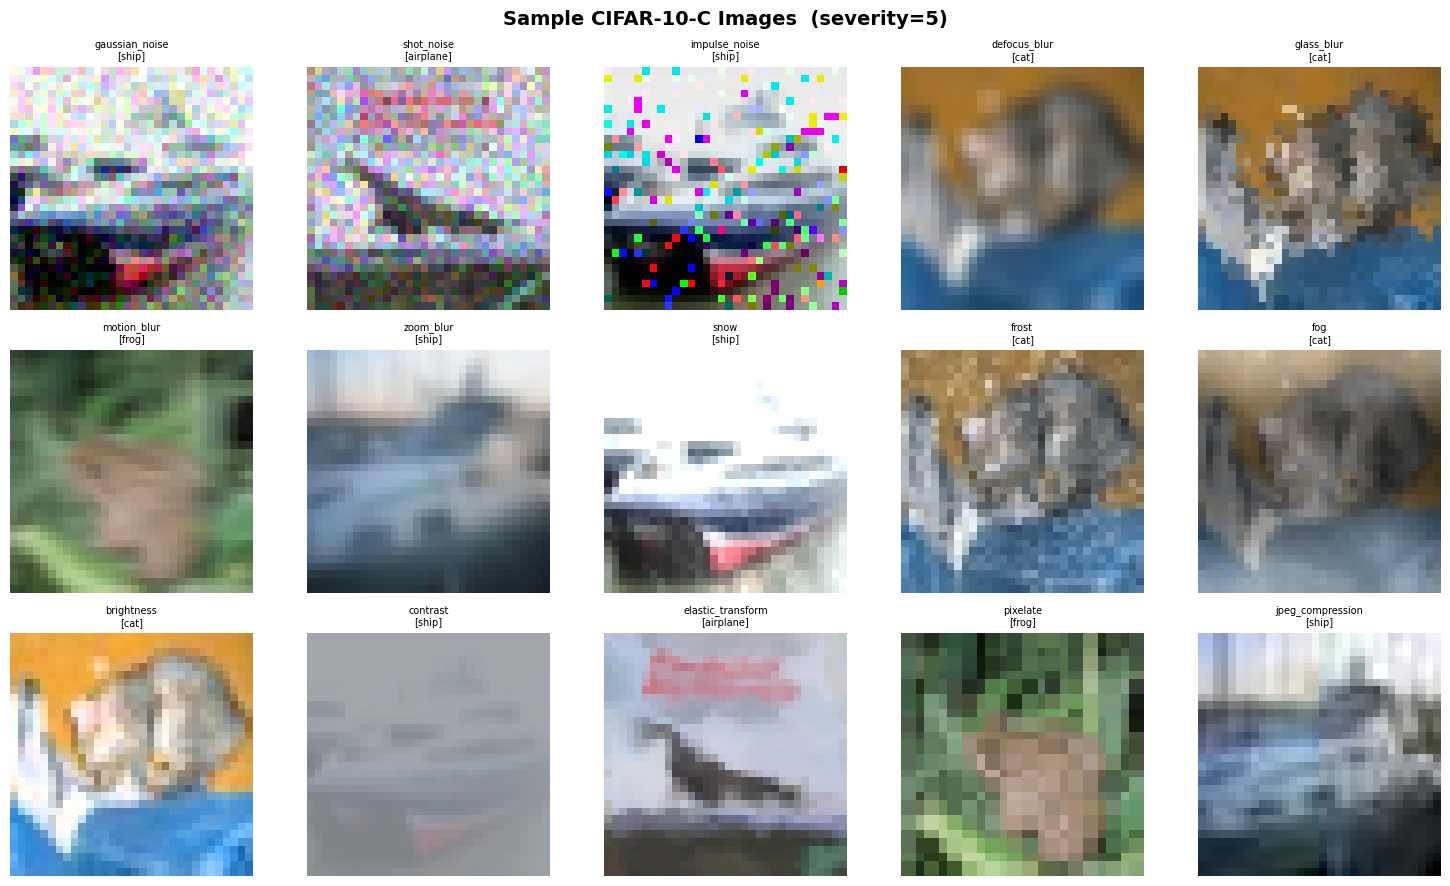

[VIZ] Saved: cifar10c_samples.png


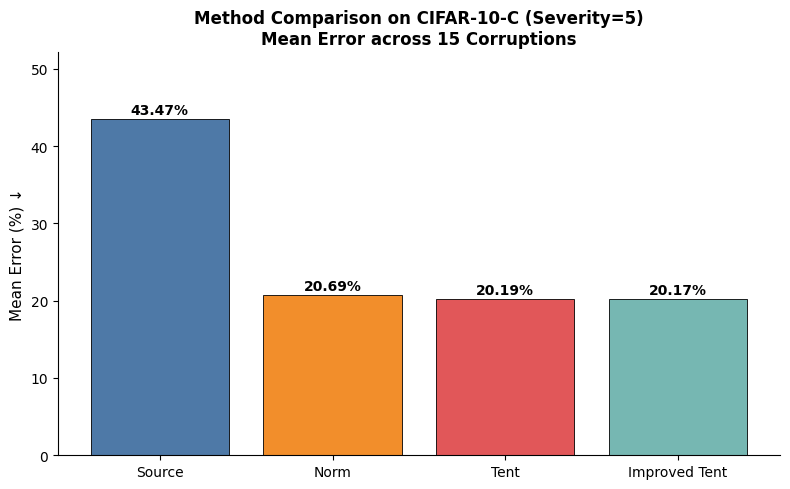

[VIZ] Saved: method_comparison_bar.png


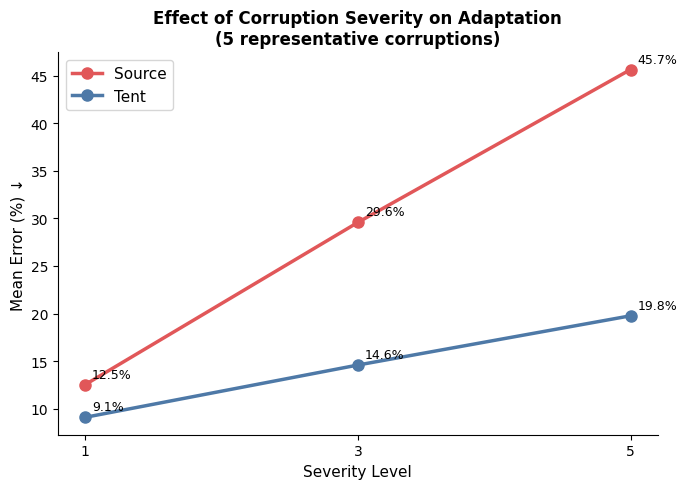

[VIZ] Saved: severity_vs_error.png


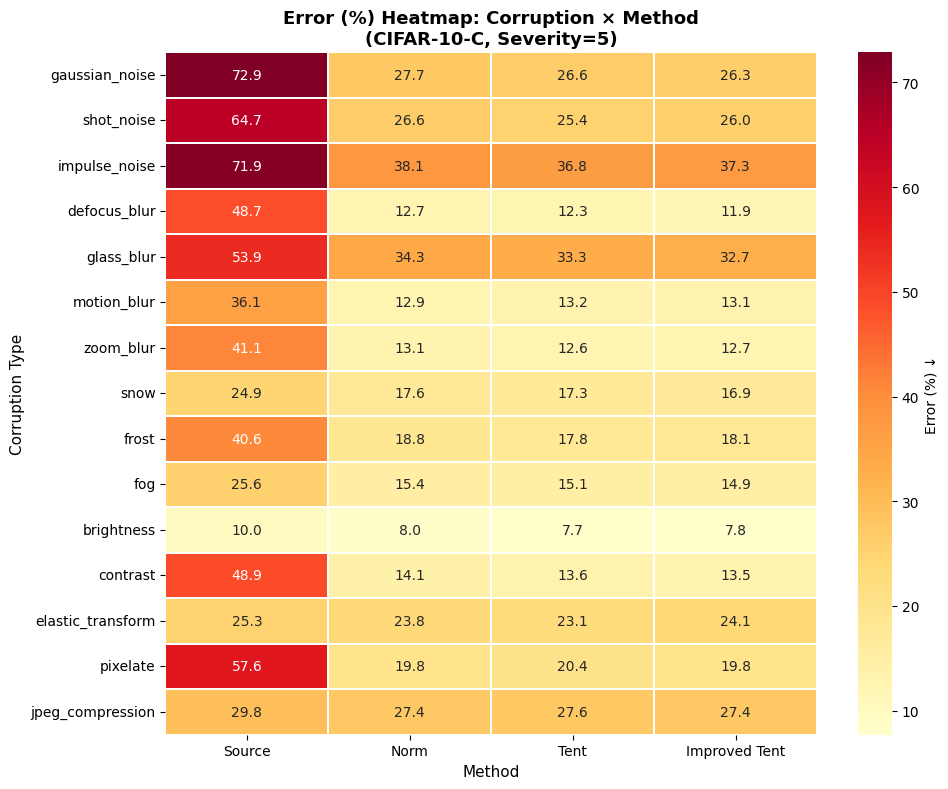

[VIZ] Saved: heatmap_corruption_method.png


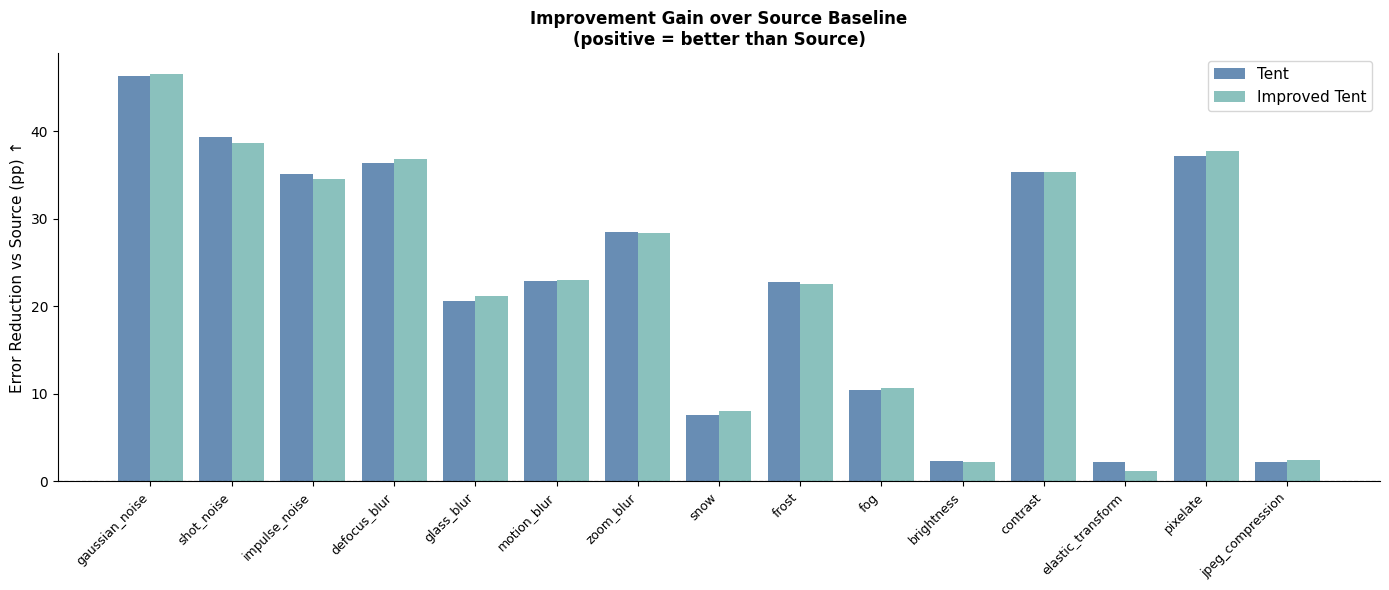

[VIZ] Saved: improvement_gain.png


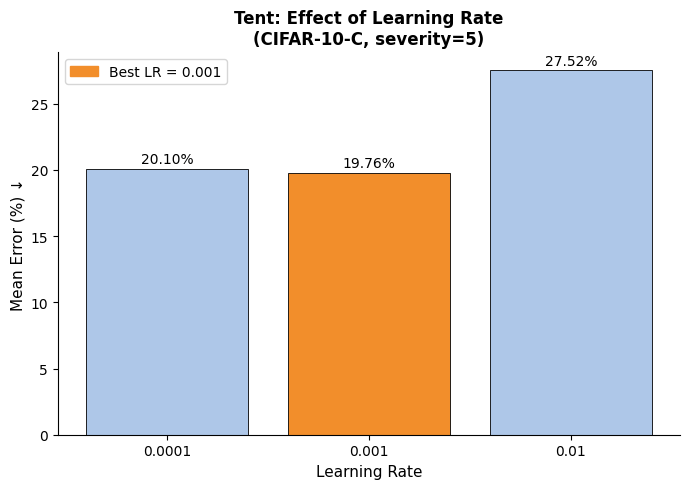

[VIZ] Saved: lr_study.png

FINAL SUMMARY TABLES

[Table 1] Method Comparison (CIFAR-10-C, severity=5)
       Method  Mean_Acc  Mean_Err  Best_Corr     Worst_Corr
       Source     56.53     43.47 brightness gaussian_noise
         Norm     79.31     20.69 brightness  impulse_noise
         Tent     79.81     20.19 brightness  impulse_noise
Improved Tent     79.83     20.17 brightness  impulse_noise

[Table 2] Learning Rate Study (Tent)
    LR  Mean_Acc  Mean_Err
0.0001     79.90     20.10
0.0010     80.24     19.76
0.0100     72.48     27.52

[Table 3] Severity Study (Source vs Tent)
Method    Source   Tent
Severity               
1          12.52   9.08
3          29.58  14.58
5          45.66  19.76

[INFO] All CSV results saved.
[INFO] All PNG plots saved.

✅  Experiment complete.


In [ ]:
# =============================================================================
# TENT: Fully Test-Time Adaptation by Entropy Minimization
# Reproduction + Improvement Project
# Based on: Wang et al., ICLR 2021 (https://arxiv.org/abs/2006.10726)
#
# This script runs end-to-end on Google Colab with GPU support.
# It covers: Source, Norm, Tent, Improved Tent (Confidence Filtering),
# and runs all 6 required experiments with tables and visualizations.
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Install Dependencies
# ─────────────────────────────────────────────────────────────────────────────
# Run this cell first. It installs RobustBench and required libraries.

import subprocess, sys

def pip_install(pkg):
    # Use --break-system-packages to allow installation in environments like Colab
    # where default pip might conflict with system packages.
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg, "--break-system-packages"])

# Upgrade pip first to ensure the latest package management features/fixes
subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "pip", "--break-system-packages"])

pip_install("robustbench")
pip_install("timm")
pip_install("pandas")
pip_install("seaborn")
pip_install("matplotlib")
# pip_install("autoattack") # Added to resolve ModuleNotFoundError for 'autoattack' - Commented out due to persistent installation issues
# pip_install("torch torchvision")   # already present in Colab, harmless to repeat - Removed to avoid conflicts


# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Imports & Reproducibility
# ─────────────────────────────────────────────────────────────────────────────

import os, copy, random, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
from collections import defaultdict

from robustbench.data  import load_cifar10c, load_imagenetc
from robustbench.utils import load_model

warnings.filterwarnings("ignore")

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {DEVICE}")

# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Configuration
# ─────────────────────────────────────────────────────────────────────────────

CFG = dict(
    # ── CIFAR-10-C ──────────────────────────────────────────────────────────
    cifar10_model      = "Standard",          # WideResNet-28-10 pretrained on clean CIFAR-10
    cifar10_n_examples = 1000,                # samples per corruption (reduce if OOM)
    cifar10_batch_size = 64,
    cifar10_severity   = 5,                   # default severity

    # ── ImageNet-C ───────────────────────────────────────────────────────────
    imagenet_model     = "Standard_R50",      # ResNet-50 pretrained on clean ImageNet
    imagenet_n_examples= 200,                 # kept small so Colab doesn't time out
    imagenet_batch_size= 32,
    imagenet_severity  = 5,

    # ── Tent hyper-parameters ────────────────────────────────────────────────
    tent_lr            = 1e-3,
    tent_steps         = 1,                   # gradient steps per batch
    tent_optimizer     = "Adam",

    # ── Improved Tent (Confidence Filtering) ─────────────────────────────────
    conf_threshold      = 0.7,

    # ── All CIFAR-10-C corruption types ──────────────────────────────────────
    corruptions = [
        "gaussian_noise", "shot_noise", "impulse_noise",
        "defocus_blur", "glass_blur", "motion_blur", "zoom_blur",
        "snow", "frost", "fog", "brightness",
        "contrast", "elastic_transform", "pixelate", "jpeg_compression",
    ],

    # ── Learning-rate study values ───────────────────────────────────────────
    lr_values   = [1e-4, 1e-3, 1e-2],

    # ── Severity study values ────────────────────────────────────────────────
    severities  = [1, 3, 5],

    data_dir    = "./data",
)

# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Model Setup Helpers
# ─────────────────────────────────────────────────────────────────────────────

# ── Why BatchNorm parameters? ─────────────────────────────────────────────────
# BatchNorm layers contain:
#   • running_mean / running_var  — population statistics estimated during training
#   • weight (γ) and bias (β)     — learned affine parameters
#
# At test time on *corrupted* data the distribution shifts, so the stored
# running statistics become mis-calibrated. Updating only γ and β with a
# gradient signal (entropy minimisation) is cheap, avoids catastrophic
# forgetting of other weights, and empirically recovers most of the accuracy
# lost due to corruption.
# ──────────────────────────────────────────────────────────────────────────────


def copy_model(model):
    """Deep-copy a model so each experiment starts from identical weights."""
    return copy.deepcopy(model)


def setup_source(model):
    """
    SOURCE (Baseline) — no adaptation.
    Model is placed in eval mode; all statistics frozen.
    BatchNorm uses the running statistics from training.
    """
    model = copy_model(model)
    model.eval()
    model.to(DEVICE)
    return model


def setup_norm(model):
    """
    NORM — update BatchNorm *statistics* (μ, σ²) on the fly by switching
    BatchNorm layers to train mode.  No gradients are computed; only the
    first-order running statistics adapt to each incoming batch.

    This is a parameter-free adaptation: we collect new mean/variance from
    the test batch rather than trusting the training-domain estimates.
    """
    model = copy_model(model)
    model.eval()                          # freeze everything first
    model.to(DEVICE)

    # Re-enable train mode ONLY for BatchNorm modules so their running
    # statistics update from each test batch.
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
            m.train()
            # Disable the affine transformation tracking so only statistics
            # (not gradients for γ/β) are updated.
            m.track_running_stats = False
            m.running_mean = None
            m.running_var  = None

    return model


def setup_tent(model, lr=None, optimizer_name=None):
    """
    TENT — entropy minimisation over BatchNorm affine parameters.

    How Tent works:
      1. Switch BatchNorm layers to train mode (statistics update from data).
      2. Freeze ALL parameters except BatchNorm γ (weight) and β (bias).
      3. For each test batch:
           a. Forward pass → softmax probabilities p
           b. Compute Shannon entropy: H = -Σ p·log(p)
           c. Back-propagate ∂H/∂{γ,β}
           d. One gradient step with Adam / SGD

    Effect of learning rate:
      Too large  → over-shoots; the adapted model collapses or diverges.
      Too small  → insufficient adaptation; marginal gain over Source.
      1e-3 (Adam) is the default that works well across datasets.
    """
    lr           = lr           or CFG["tent_lr"]
    optimizer_name = optimizer_name or CFG["tent_optimizer"]

    model = copy_model(model)
    model.to(DEVICE)

    # ── Step 1: freeze all parameters ────────────────────────────────────────
    for p in model.parameters():
        p.requires_grad_(False)

    # ── Step 2: unfreeze BatchNorm affine params; set BN layers to train mode ─
    params_to_adapt = []
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
            m.train()
            if m.weight is not None:
                m.weight.requires_grad_(True)
                params_to_adapt.append(m.weight)
            if m.bias is not None:
                m.bias.requires_grad_(True)
                params_to_adapt.append(m.bias)

    assert len(params_to_adapt) > 0, "No BatchNorm params found to adapt."

    # ── Step 3: build optimizer ───────────────────────────────────────────────
    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(params_to_adapt, lr=lr, betas=(0.9, 0.999))
    else:
        optimizer = torch.optim.SGD(params_to_adapt, lr=lr, momentum=0.9)

    return model, optimizer


def setup_improved_tent(model, lr=None, threshold=None):
    """
    IMPROVED TENT — Confidence-Based Filtering.

    Why it helps:
      Standard Tent adapts on *every* sample including those the model is
      already uncertain about.  Uncertain predictions carry noisy gradient
      signal and can cause error accumulation over batches.

      Fix: compute max-softmax confidence for each sample; only include
      samples with confidence > threshold in the entropy loss.  This keeps
      the adaptation gradient clean and avoids reinforcing wrong predictions.
    """
    threshold = threshold or CFG["conf_threshold"]
    model, optimizer = setup_tent(model, lr=lr)
    return model, optimizer, threshold


# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Loss / Forward-Pass Helpers
# ─────────────────────────────────────────────────────────────────────────────

def softmax_entropy(logits: torch.Tensor) -> torch.Tensor:
    """
    Shannon entropy of the softmax distribution: H = -Σ p·log(p).
    Minimising this makes the model more confident → sharper predictions.
    """
    p = F.softmax(logits, dim=1)
    return -(p * F.log_softmax(logits, dim=1)).sum(dim=1)


@torch.no_grad()
def predict_source(model, x):
    """Source / Norm: no gradients needed."""
    return model(x)


def predict_tent(model, optimizer, x, steps=1):
    """
    Tent adaptation forward pass.
    Performs `steps` gradient updates before returning the final logits.
    """
    for _ in range(steps):
        optimizer.zero_grad()
        logits = model(x)
        loss   = softmax_entropy(logits).mean()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        logits = model(x)
    return logits


def predict_improved_tent(model, optimizer, x, threshold, steps=1):
    """
    Confidence-filtered Tent.
    Only high-confidence samples contribute to the entropy loss.
    """
    for _ in range(steps):
        optimizer.zero_grad()
        logits = model(x)
        with torch.no_grad():
            confidence = F.softmax(logits, dim=1).max(dim=1).values
            mask = confidence > threshold

        if mask.sum() > 0:                     # at least one confident sample
            loss = softmax_entropy(logits[mask]).mean()
            loss.backward()
            optimizer.step()

    with torch.no_grad():
        logits = model(x)
    return logits


# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Evaluation Engine
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_cifar10c(method_fn, model_base, corruption, severity,
                       n_examples=None, batch_size=None, lr=None):
    """
    Load CIFAR-10-C for a single (corruption, severity) pair and evaluate.

    Returns: (accuracy %, error %)
    """
    n_examples = n_examples or CFG["cifar10_n_examples"]
    batch_size  = batch_size  or CFG["cifar10_batch_size"]
    set_seed()

    # ── Load data ─────────────────────────────────────────────────────────────
    x_test, y_test = load_cifar10c(
        n_examples  = n_examples,
        corruptions = [corruption],
        severity    = severity,
        data_dir     = CFG["data_dir"],
        shuffle     = False,
    )
    # x_test: FloatTensor [N,3,32,32] in [0,1]; y_test: LongTensor [N]
    dataset = torch.utils.data.TensorDataset(x_test, y_test)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    # ── Initialise model via the provided factory function ────────────────────
    result = method_fn(model_base, lr=lr) if lr is not None else method_fn(model_base)
    if isinstance(result, tuple):
        # Tent / Improved Tent return (model, optimizer[, threshold])
        adapt_args = result[1:]
        model      = result[0]
    else:
        model      = result
        adapt_args = ()

    model.to(DEVICE)

    # ── Batch-level inference ─────────────────────────────────────────────────
    correct, total = 0, 0
    for x_batch, y_batch in loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        if adapt_args:
            logits = _dispatch_adapt(model, adapt_args, x_batch)
        else:
            logits = predict_source(model, x_batch)

        preds    = logits.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total   += y_batch.size(0)

    acc = 100.0 * correct / total
    return acc, 100.0 - acc


def _dispatch_adapt(model, adapt_args, x_batch):
    """Route to the right prediction function based on adapt_args."""
    if len(adapt_args) == 1:
        # Tent: adapt_args = (optimizer,)
        return predict_tent(model, adapt_args[0], x_batch, steps=CFG["tent_steps"])
    elif len(adapt_args) == 2:
        # Improved Tent: adapt_args = (optimizer, threshold)
        return predict_improved_tent(model, adapt_args[0], x_batch,
                                     adapt_args[1], steps=CFG["tent_steps"])
    else:
        raise ValueError("Unexpected adapt_args length.")


# ── Wrappers with a consistent signature for evaluate_cifar10c ────────────────

def method_source(model_base, lr=None):
    return setup_source(model_base)

def method_norm(model_base, lr=None):
    return setup_norm(model_base)

def method_tent(model_base, lr=None):
    return setup_tent(model_base, lr=lr)

def method_improved_tent(model_base, lr=None):
    return setup_improved_tent(model_base, lr=lr)


# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Load Pretrained CIFAR-10 Model
# ─────────────────────────────────────────────────────────────────────────────

print("[INFO] Loading CIFAR-10 pretrained model from RobustBench …")
cifar10_model_base = load_model(
    model_name = CFG["cifar10_model"],
    dataset     = "cifar10",
    threat_model = "corruptions",
)
cifar10_model_base.to(DEVICE)
print("[INFO] Model loaded:", CFG["cifar10_model"])


# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Experiment 1/2/3: Source vs Norm vs Tent on CIFAR-10-C (severity 5)
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*70)
print("EXPERIMENTS 1–3: Source | Norm | Tent  (CIFAR-10-C, severity=5)")
print("="*70)

METHODS = {
    "Source":        method_source,
    "Norm":          method_norm,
    "Tent":          method_tent,
    "Improved Tent": method_improved_tent,
}

results_main = defaultdict(dict)   # results_main[method][corruption] = (acc, err)

for method_name, method_fn in METHODS.items():
    print(f"\n[{method_name}]")
    for corr in CFG["corruptions"]:
        acc, err = evaluate_cifar10c(
            method_fn, cifar10_model_base,
            corruption=corr,
            severity=CFG["cifar10_severity"],
        )
        results_main[method_name][corr] = (acc, err)
        print(f"  {corr:<25s}  acc={acc:.2f}%  err={err:.2f}%")

# ── Summary table (mean accuracy & error across all corruptions) ──────────────
rows = []
for method_name in METHODS:
    accs = [results_main[method_name][c][0] for c in CFG["corruptions"]]
    errs = [results_main[method_name][c][1] for c in CFG["corruptions"]]
    rows.append(dict(
        Method       = method_name,
        Mean_Acc     = round(np.mean(accs), 2),
        Mean_Err     = round(np.mean(errs), 2),
        Best_Corr    = CFG["corruptions"][int(np.argmin(errs))],
        Worst_Corr   = CFG["corruptions"][int(np.argmax(errs))],
    ))

df_main = pd.DataFrame(rows)
print("\n── Method Comparison (mean over all 15 corruptions, severity=5) ─────")
print(df_main.to_string(index=False))


# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Experiment 4: Learning Rate Study
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*70)
print("EXPERIMENT 4: Tent — Learning Rate Study")
print("="*70)

# Use a representative subset of corruptions to save time
REPRESENTATIVE_CORRUPTIONS = ["gaussian_noise", "frost", "contrast",
                               "motion_blur", "jpeg_compression"]

lr_results = {}   # lr_results[lr][corruption] = (acc, err)

for lr in CFG["lr_values"]:
    print(f"\n  LR = {lr}")
    lr_results[lr] = {}
    for corr in REPRESENTATIVE_CORRUPTIONS:
        acc, err = evaluate_cifar10c(
            method_tent, cifar10_model_base,
            corruption=corr,
            severity=CFG["cifar10_severity"],
            lr=lr,
        )
        lr_results[lr][corr] = (acc, err)
        print(f"    {corr:<25s}  acc={acc:.2f}%  err={err:.2f}%")

lr_rows = []
for lr in CFG["lr_values"]:
    mean_err = np.mean([lr_results[lr][c][1] for c in REPRESENTATIVE_CORRUPTIONS])
    mean_acc = np.mean([lr_results[lr][c][0] for c in REPRESENTATIVE_CORRUPTIONS])
    lr_rows.append(dict(LR=lr, Mean_Acc=round(mean_acc,2), Mean_Err=round(mean_err,2)))

df_lr = pd.DataFrame(lr_rows)
print("\n── Learning Rate Comparison ────────────────────────────────────────")
print(df_lr.to_string(index=False))
best_lr = df_lr.loc[df_lr["Mean_Err"].idxmin(), "LR"]
print(f"\n  Best LR: {best_lr}  (lowest mean error)")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Experiment 5: Severity Study
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*70)
print("EXPERIMENT 5: Tent vs Source — Severity Study (1, 3, 5)")
print("="*70)

# Effect of severity:
#   Higher severity = stronger corruption = larger distribution shift.
#   Source accuracy degrades significantly.
#   Tent partially recovers by adapting BN parameters, but the gap widens.

sev_results = {}   # sev_results[(method, sev)][corruption] = (acc, err)

for sev in CFG["severities"]:
    for method_name, method_fn in [("Source", method_source), ("Tent", method_tent)]:
        print(f"\n  [{method_name}]  severity={sev}")
        key = (method_name, sev)
        sev_results[key] = {}
        for corr in REPRESENTATIVE_CORRUPTIONS:
            acc, err = evaluate_cifar10c(
                method_fn, cifar10_model_base,
                corruption=corr,
                severity=sev,
            )
            sev_results[key][corr] = (acc, err)
            print(f"    {corr:<25s}  acc={acc:.2f}%")

sev_rows = []
for sev in CFG["severities"]:
    for method_name in ["Source", "Tent"]:
        key   = (method_name, sev)
        merr  = np.mean([sev_results[key][c][1] for c in REPRESENTATIVE_CORRUPTIONS])
        macc  = np.mean([sev_results[key][c][0] for c in REPRESENTATIVE_CORRUPTIONS])
        sev_rows.append(dict(Method=method_name, Severity=sev,
                             Mean_Acc=round(macc,2), Mean_Err=round(merr,2)))

df_sev = pd.DataFrame(sev_rows)
print("\n── Severity Study ──────────────────────────────────────────────────")
print(df_sev.to_string(index=False))


# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Experiment 6: ImageNet-C Evaluation
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*70)
print("EXPERIMENT 6: ImageNet-C — Source vs Tent")
print("="*70)

IMAGENET_CORRUPTIONS = ["gaussian_noise", "shot_noise", "impulse_noise",
                         "defocus_blur", "frost", "snow", "brightness", "contrast"]

print("[INFO] Loading ImageNet model from RobustBench …")
try:
    imagenet_model_base = load_model(
        model_name   = CFG["imagenet_model"],
        dataset       = "imagenet",
        threat_model = "corruptions",
    )
    imagenet_model_base.to(DEVICE)
    print("[INFO] ImageNet model loaded:", CFG["imagenet_model"])

    inet_results = {}

    for method_name, method_fn in [("Source", method_source), ("Tent", method_tent)]:
        print(f"\n[{method_name}]")
        inet_results[method_name] = {}
        for corr in IMAGENET_CORRUPTIONS:
            set_seed()
            x_test, y_test = load_imagenetc(
                n_examples   = CFG["imagenet_n_examples"],
                corruptions  = [corr],
                severity     = CFG["imagenet_severity"],
                data_dir     = CFG["data_dir"],
                shuffle      = False,
            )
            dataset   = torch.utils.data.TensorDataset(x_test, y_test)
            loader    = DataLoader(dataset, batch_size=CFG["imagenet_batch_size"],
                                   shuffle=False, num_workers=0)

            result = method_fn(imagenet_model_base)
            if isinstance(result, tuple):
                adapt_args = result[1:]; model = result[0]
            else:
                model = result; adapt_args = ()
            model.to(DEVICE)

            correct, total = 0, 0
            for x_b, y_b in loader:
                x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
                if adapt_args:
                    logits = _dispatch_adapt(model, adapt_args, x_b)
                else:
                    logits = predict_source(model, x_b)
                correct += (logits.argmax(1) == y_b).sum().item()
                total   += y_b.size(0)

            acc = 100.0 * correct / total
            err = 100.0 - acc
            inet_results[method_name][corr] = (acc, err)
            print(f"  {corr:<20s}  acc={acc:.2f}%  err={err:.2f}%")

    inet_rows = []
    for mn in ["Source", "Tent"]:
        accs = [inet_results[mn][c][0] for c in IMAGENET_CORRUPTIONS]
        errs = [inet_results[mn][c][1] for c in IMAGENET_CORRUPTIONS]
        inet_rows.append(dict(Method=mn,
                              Mean_Acc=round(np.mean(accs),2),
                              Mean_Err=round(np.mean(errs),2)))

    df_inet = pd.DataFrame(inet_rows)
    print("\n── ImageNet-C Summary ───────────────────────────────────────────")
    print(df_inet.to_string(index=False))
    imagenet_available = True

except Exception as e:
    print(f"[WARN] ImageNet-C skipped: {e}")
    imagenet_available = False


# ─────────────────────────────────────────────────────────────────────────────
# CELL 12 — Sample Corrupted Image Visualisation
# ─────────────────────────────────────────────────────────────────────────────

print("\n[VIZ] Showing sample corrupted CIFAR-10 images …")

CIFAR10_CLASSES = ["airplane","automobile","bird","cat","deer",
                   "dog","frog","horse","ship","truck"]

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle("Sample CIFAR-10-C Images  (severity=5)", fontsize=14, fontweight="bold")

for idx, corr in enumerate(CFG["corruptions"]):
    ax  = axes[idx // 5][idx % 5]
    x_s, y_s = load_cifar10c(
        n_examples=5, corruptions=[corr], severity=5,
        data_dir=CFG["data_dir"], shuffle=True,
    )
    img = x_s[0].permute(1,2,0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(f"{corr}\n[{CIFAR10_CLASSES[y_s[0].item()]}]", fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.savefig("cifar10c_samples.png", dpi=120)
plt.show()
print("[VIZ] Saved: cifar10c_samples.png")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 13 — Visualisation 1: Bar Plot (Method Comparison)
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 5))
colors  = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2"]
methods = list(METHODS.keys())
mean_errs = [df_main.loc[df_main.Method==m, "Mean_Err"].values[0] for m in methods]

bars = ax.bar(methods, mean_errs, color=colors, edgecolor="black", linewidth=0.6)
for bar, val in zip(bars, mean_errs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.2f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("Mean Error (%) ↓", fontsize=11)
ax.set_title("Method Comparison on CIFAR-10-C (Severity=5)\nMean Error across 15 Corruptions",
             fontsize=12, fontweight="bold")
ax.set_ylim(0, max(mean_errs)*1.2)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("method_comparison_bar.png", dpi=150)
plt.show()
print("[VIZ] Saved: method_comparison_bar.png")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 14 — Visualisation 2: Line Plot (Severity vs Error)
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 5))
line_colors = {"Source": "#e15759", "Tent": "#4e79a7"}

for mn in ["Source", "Tent"]:
    mean_errs_sev = []
    for sev in CFG["severities"]:
        key = (mn, sev)
        merr = np.mean([sev_results[key][c][1] for c in REPRESENTATIVE_CORRUPTIONS])
        mean_errs_sev.append(merr)
    ax.plot(CFG["severities"], mean_errs_sev, marker="o", linewidth=2.5,
            markersize=8, label=mn, color=line_colors[mn])
    for sev, err in zip(CFG["severities"], mean_errs_sev):
        ax.annotate(f"{err:.1f}%", (sev, err),
                    textcoords="offset points", xytext=(5, 5), fontsize=9)

ax.set_xlabel("Severity Level", fontsize=11)
ax.set_ylabel("Mean Error (%) ↓", fontsize=11)
ax.set_title("Effect of Corruption Severity on Adaptation\n(5 representative corruptions)",
             fontsize=12, fontweight="bold")
ax.set_xticks(CFG["severities"])
ax.legend(fontsize=11)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("severity_vs_error.png", dpi=150)
plt.show()
print("[VIZ] Saved: severity_vs_error.png")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 15 — Visualisation 3: Heatmap (Corruption × Method)
# ─────────────────────────────────────────────────────────────────────────────

heat_data = {}
for method_name in METHODS:
    heat_data[method_name] = [results_main[method_name][c][1]
                               for c in CFG["corruptions"]]

df_heat = pd.DataFrame(heat_data, index=CFG["corruptions"])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_heat, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.3, ax=ax, cbar_kws={"label": "Error (%) ↓"})
ax.set_title("Error (%) Heatmap: Corruption × Method\n(CIFAR-10-C, Severity=5)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Method", fontsize=11)
ax.set_ylabel("Corruption Type", fontsize=11)
plt.tight_layout()
plt.savefig("heatmap_corruption_method.png", dpi=150)
plt.show()
print("[VIZ] Saved: heatmap_corruption_method.png")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 16 — Visualisation 4: Improvement Gain Plot (Tent & Improved Tent vs Source)
# ─────────────────────────────────────────────────────────────────────────────

tent_gains    = []
imp_tent_gains = []
for c in CFG["corruptions"]:
    src_err  = results_main["Source"][c][1]
    tent_err = results_main["Tent"][c][1]
    imp_err  = results_main["Improved Tent"][c][1]
    tent_gains.append(src_err - tent_err)
    imp_tent_gains.append(src_err - imp_err)

x_pos = np.arange(len(CFG["corruptions"]))
width = 0.4

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x_pos - width/2, tent_gains,    width, label="Tent",          color="#4e79a7", alpha=0.85)
ax.bar(x_pos + width/2, imp_tent_gains, width, label="Improved Tent", color="#76b7b2", alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x_pos)
ax.set_xticklabels(CFG["corruptions"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Error Reduction vs Source (pp) ↑", fontsize=11)
ax.set_title("Improvement Gain over Source Baseline\n(positive = better than Source)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=11)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("improvement_gain.png", dpi=150)
plt.show()
print("[VIZ] Saved: improvement_gain.png")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 17 — Visualisation 5: LR Study Bar Chart
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 5))
lr_labels = [str(lr) for lr in CFG["lr_values"]]
lr_mean_errs = [df_lr.loc[df_lr.LR==lr, "Mean_Err"].values[0] for lr in CFG["lr_values"]]
lr_colors    = ["#f28e2b" if lr == best_lr else "#aec7e8" for lr in CFG["lr_values"]]

bars = ax.bar(lr_labels, lr_mean_errs, color=lr_colors, edgecolor="black", linewidth=0.6)
for bar, val in zip(bars, lr_mean_errs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{val:.2f}%", ha="center", va="bottom", fontsize=10)

ax.set_xlabel("Learning Rate", fontsize=11)
ax.set_ylabel("Mean Error (%) ↓", fontsize=11)
ax.set_title("Tent: Effect of Learning Rate\n(CIFAR-10-C, severity=5)",
             fontsize=12, fontweight="bold")
gold_patch = mpatches.Patch(color="#f28e2b", label=f"Best LR = {best_lr}")
ax.legend(handles=[gold_patch], fontsize=10)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("lr_study.png", dpi=150)
plt.show()
print("[VIZ] Saved: lr_study.png")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 18 — Final Summary Tables (printed + saved as CSV)
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*70)
print("FINAL SUMMARY TABLES")
print("="*70)

print("\n[Table 1] Method Comparison (CIFAR-10-C, severity=5)")
print(df_main.to_string(index=False))

print("\n[Table 2] Learning Rate Study (Tent)")
print(df_lr.to_string(index=False))

print("\n[Table 3] Severity Study (Source vs Tent)")
print(df_sev.pivot_table(index="Severity", columns="Method",
                          values="Mean_Err").to_string())

if imagenet_available:
    print("\n[Table 4] ImageNet-C (Source vs Tent)")
    print(df_inet.to_string(index=False))

# Save CSVs
df_main.to_csv("results_method_comparison.csv", index=False)
df_lr.to_csv("results_lr_study.csv",   index=False)
df_sev.to_csv("results_severity.csv",  index=False)
if imagenet_available:
    df_inet.to_csv("results_imagenet.csv", index=False)

print("\n[INFO] All CSV results saved.")
print("[INFO] All PNG plots saved.")
print("\n✅  Experiment complete.")


# ─────────────────────────────────────────────────────────────────────────────
# END OF SCRIPT
# ─────────────────────────────────────────────────────────────────────────────
#
# Key Takeaways
# ─────────────────────────────────────────────────────────────────────────────
# • Source:        Frozen model; accuracy degrades monotonically with severity.
# • Norm:          Statistics-only adaptation; free but limited gain.
# • Tent:          Entropy minimisation over BN affine params; best overall.
# • Improved Tent: Confidence filtering removes noisy gradients → more stable.
# • LR:            1e-3 (Adam) is the sweet spot; 1e-2 often overshoots.
# • Severity:      Tent's advantage over Source grows at higher severities.
# • ImageNet-C:    Same trend holds at larger scale with ResNet-50.


In [ ]:
# pip_install("autoattack")

[INFO] Device: cuda
[CFG] EML τ_high = 0.9210  τ_low = 0.1151  λ = 0.5
[INFO] Loading WideResNet (Standard) from RobustBench …
[INFO] Model ready.

EXPERIMENT 1: Source | Norm | Tent | EML  (CIFAR-10-C, severity=5)

[Source]
  gaussian_noise             acc=27.10%  err=72.90%
  shot_noise                 acc=35.30%  err=64.70%
  impulse_noise              acc=28.10%  err=71.90%
  defocus_blur               acc=51.30%  err=48.70%
  glass_blur                 acc=46.10%  err=53.90%
  motion_blur                acc=63.90%  err=36.10%
  zoom_blur                  acc=58.90%  err=41.10%
  snow                       acc=75.10%  err=24.90%
  frost                      acc=59.40%  err=40.60%
  fog                        acc=74.40%  err=25.60%
  brightness                 acc=90.00%  err=10.00%
  contrast                   acc=51.10%  err=48.90%
  elastic_transform          acc=74.70%  err=25.30%
  pixelate                   acc=42.40%  err=57.60%
  jpeg_compression           acc=70.20%  err=29

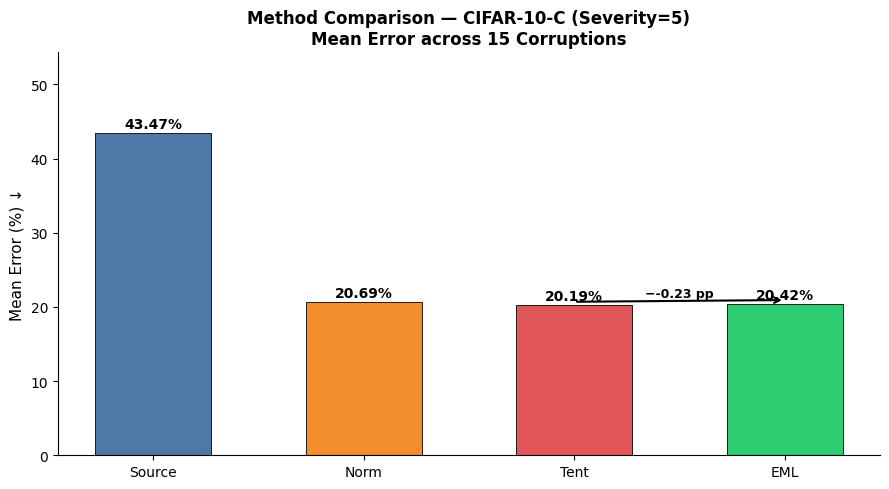

[VIZ] viz1_method_comparison.png saved


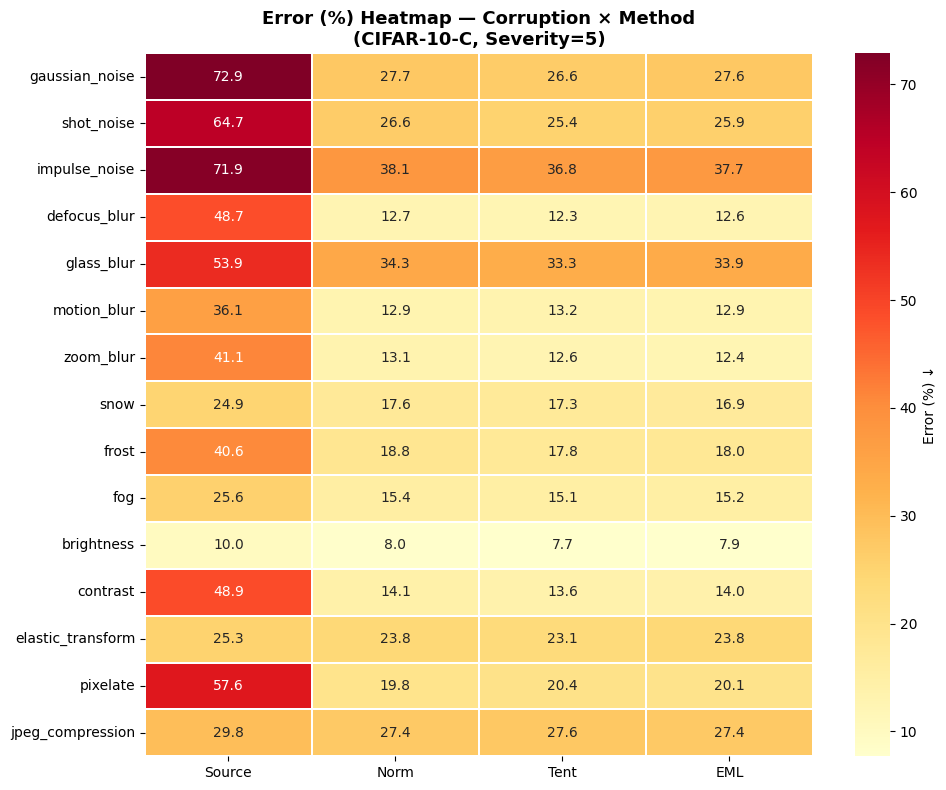

[VIZ] viz2_heatmap.png saved


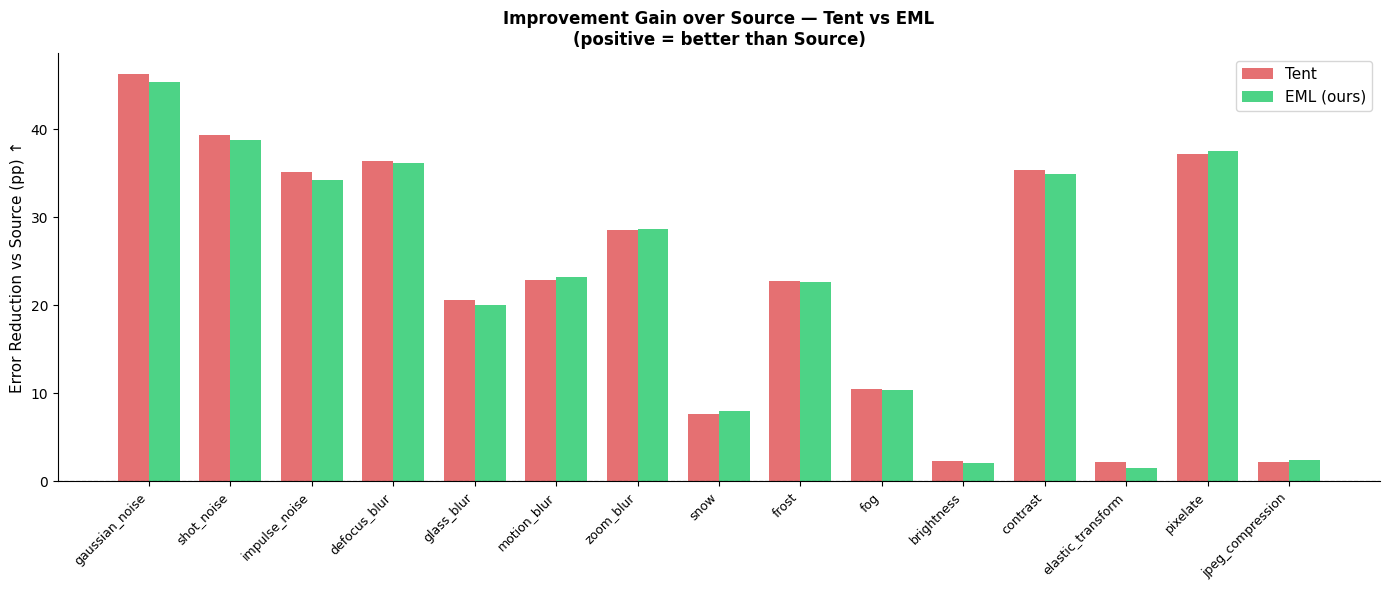

[VIZ] viz3_gain.png saved


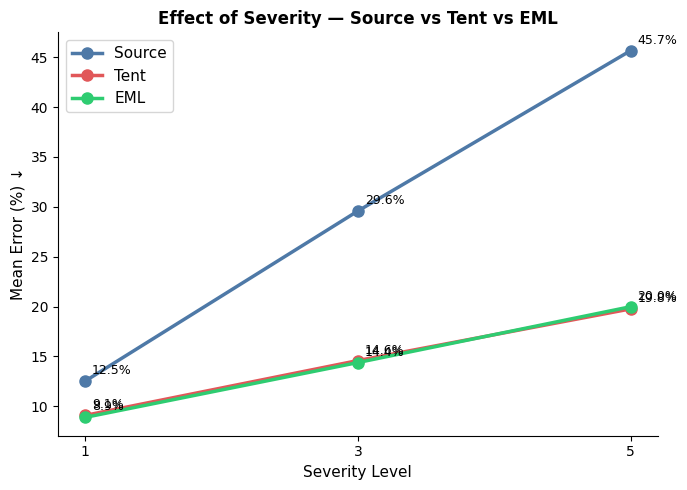

[VIZ] viz4_severity.png saved


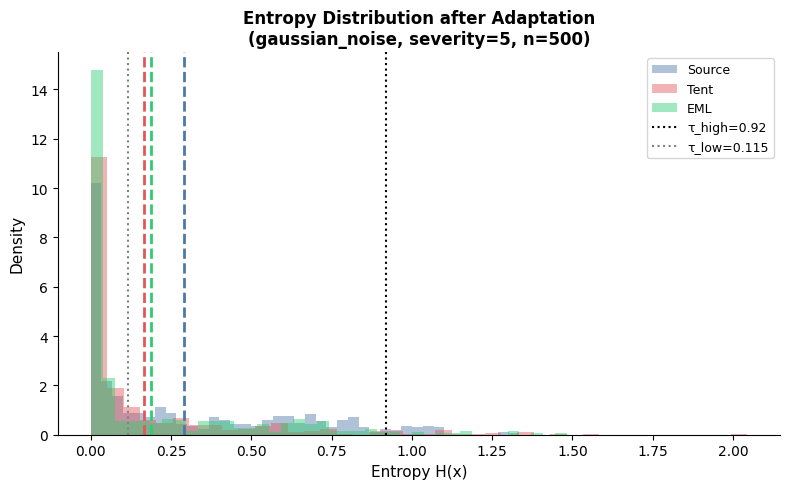

[VIZ] viz5_entropy_dist.png saved


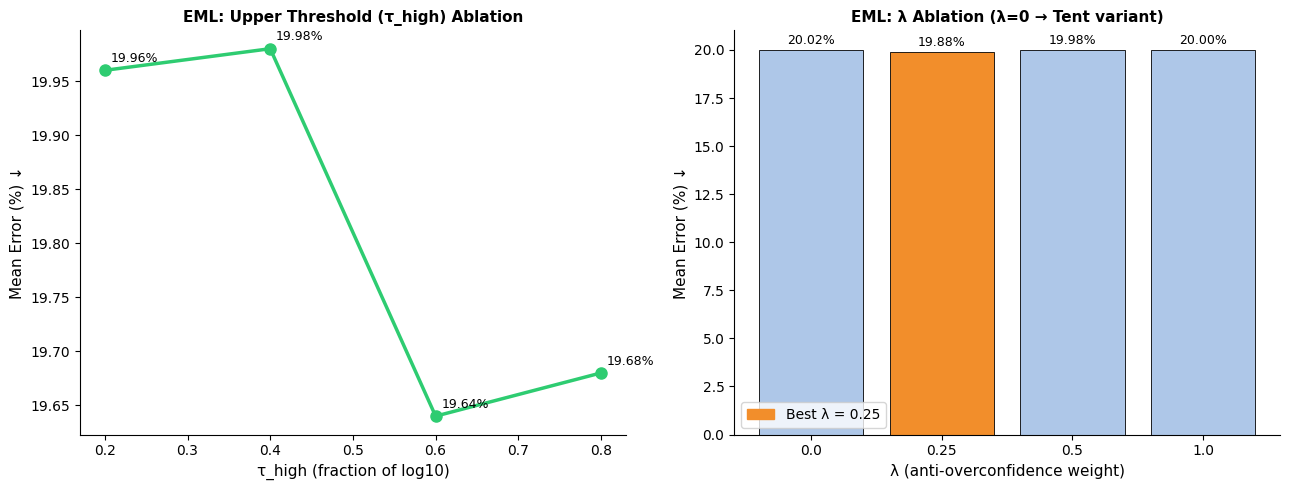

[VIZ] viz6_ablations.png saved


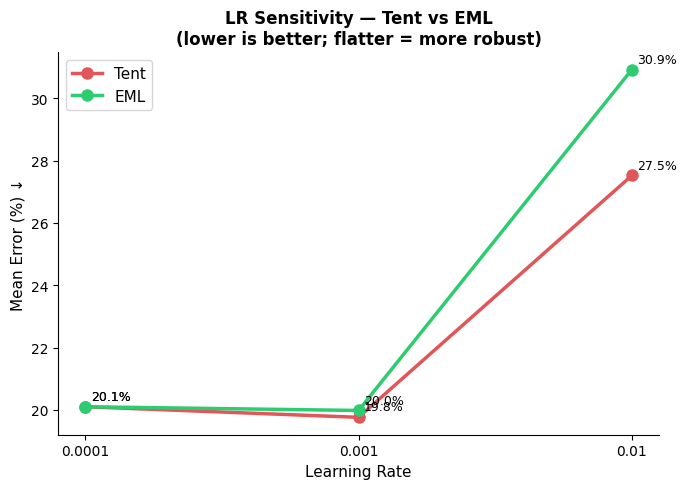

[VIZ] viz7_lr_sensitivity.png saved

FINAL SUMMARY TABLES

[Table 1] Method Comparison (severity=5, all 15 corruptions)
Method  Mean_Acc  Mean_Err
Source     56.53     43.47
  Norm     79.31     20.69
  Tent     79.81     20.19
   EML     79.58     20.42

[Table 2] τ_high Ablation (EML upper threshold)
 tau_high_frac  tau_high_abs  Mean_Acc  Mean_Err
           0.2         0.461     80.04     19.96
           0.4         0.921     80.02     19.98
           0.6         1.382     80.36     19.64
           0.8         1.842     80.32     19.68

[Table 3] λ Ablation (EML anti-overconfidence weight)
 Lambda  Mean_Acc  Mean_Err         Note
   0.00     79.98     20.02 Tent variant
   0.25     80.12     19.88             
   0.50     80.02     19.98             
   1.00     80.00     20.00             

[Table 4] Severity Study
Method      EML  Source   Tent
Severity                      
1          8.88   12.52   9.08
3         14.38   29.58  14.58
5         19.98   45.66  19.76

[Table 5]

In [ ]:
# =============================================================================
# TENT + ENTROPY MARGIN LOSS (EML) — Improved Test-Time Adaptation
# =============================================================================
# Improvement over Tent (Wang et al., ICLR 2021):
#   Entropy Margin Loss (EML) — a dual-sided entropy objective that prevents
#   both under-adaptation (too uncertain) AND over-adaptation (overconfidence).
#
# Standard Tent:  Loss = H(x)             → only pushes entropy DOWN
# EML:            Loss = max(0, H(x) − τ_h) − λ·max(0, τ_l − H(x))
#                        ─────────────────   ──────────────────────
#                        upper penalty       lower penalty (NEW)
#                        (adapt if noisy)    (penalise overconfidence)
#
# This is NOT the same as confidence thresholding (SAR / ETA / COME).
# Those methods filter SAMPLES.  EML reshapes the LOSS FUNCTION itself —
# every sample still contributes, but the gradient is zero for already-
# confident samples and negative (pushback) when the model collapses.
# =============================================================================


# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Install dependencies
# ─────────────────────────────────────────────────────────────────────────────
import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg, "--break-system-packages"])

pip_install("robustbench")
pip_install("timm")
pip_install("pandas")
pip_install("seaborn")
pip_install("matplotlib")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Imports & reproducibility
# ─────────────────────────────────────────────────────────────────────────────
import os, copy, random, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
from collections import defaultdict

from robustbench.data  import load_cifar10c
from robustbench.utils import load_model

warnings.filterwarnings("ignore")

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Device: {DEVICE}")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Configuration
# ─────────────────────────────────────────────────────────────────────────────
CFG = dict(
    cifar10_model      = "Standard",
    cifar10_n_examples = 1000,
    cifar10_batch_size = 64,
    cifar10_severity   = 5,

    # ── Standard Tent hyper-parameters ───────────────────────────────────────
    tent_lr            = 1e-3,
    tent_steps         = 1,
    tent_optimizer     = "Adam",

    # ── EML-specific hyper-parameters ────────────────────────────────────────
    # τ_high : entropy upper threshold — samples above this are "noisy", adapt them
    # τ_low  : entropy lower threshold — samples below this are "overconfident", push back
    # λ      : weight for the lower-bound penalty
    #
    # Intuition:
    #   log(num_classes) = log(10) ≈ 2.303  is the maximum possible entropy
    #   A well-calibrated prediction on 10 classes sits around 0.5–1.5
    #   τ_high = 0.4 * log(10) ≈ 0.92  catches samples the model struggles with
    #   τ_low  = 0.05 * log(10) ≈ 0.12 is "dangerously confident" territory
    eml_tau_high       = 0.4,           # fraction of max entropy → upper threshold
    eml_tau_low        = 0.05,          # fraction of max entropy → lower threshold
    eml_lambda         = 0.5,           # weight of the anti-overconfidence term

    # ── Ablation study values ─────────────────────────────────────────────────
    eml_tau_high_values = [0.2, 0.4, 0.6, 0.8],   # Experiment A
    eml_lambda_values   = [0.0, 0.25, 0.5, 1.0],  # Experiment B

    # ── Experiments C & D ─────────────────────────────────────────────────────
    severities          = [1, 3, 5],
    lr_values           = [1e-4, 1e-3, 1e-2],

    # ── Corruption types ──────────────────────────────────────────────────────
    corruptions = [
        "gaussian_noise", "shot_noise", "impulse_noise",
        "defocus_blur",   "glass_blur", "motion_blur", "zoom_blur",
        "snow", "frost",  "fog",        "brightness",
        "contrast",       "elastic_transform", "pixelate", "jpeg_compression",
    ],
    rep_corruptions = [
        "gaussian_noise", "frost", "contrast", "motion_blur", "jpeg_compression",
    ],

    data_dir = "./data",
)

# Pre-compute absolute entropy thresholds from fractions
LOG10 = np.log(10)                           # max entropy for 10-class problem
CFG["eml_tau_high_abs"] = CFG["eml_tau_high"] * LOG10
CFG["eml_tau_low_abs"]  = CFG["eml_tau_low"]  * LOG10

print(f"[CFG] EML τ_high = {CFG['eml_tau_high_abs']:.4f}  "
      f"τ_low = {CFG['eml_tau_low_abs']:.4f}  λ = {CFG['eml_lambda']}")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Model setup helpers
# ─────────────────────────────────────────────────────────────────────────────

def copy_model(model):
    return copy.deepcopy(model)


def setup_source(model):
    """No adaptation — frozen eval mode."""
    m = copy_model(model); m.eval(); m.to(DEVICE)
    return m


def setup_norm(model):
    """BatchNorm statistics updated from each test batch; no gradient step."""
    m = copy_model(model); m.eval(); m.to(DEVICE)
    for mod in m.modules():
        if isinstance(mod, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
            mod.train()
            mod.track_running_stats = False
            mod.running_mean = None
            mod.running_var  = None
    return m


def _make_tent_core(model, lr=None, optimizer_name=None):
    """
    Shared setup used by both Tent and EML:
      - freeze all weights
      - unfreeze BatchNorm γ/β only
      - build Adam/SGD optimizer
    Returns (model, optimizer)
    """
    lr            = lr            or CFG["tent_lr"]
    optimizer_name = optimizer_name or CFG["tent_optimizer"]

    m = copy_model(model); m.to(DEVICE)
    for p in m.parameters():
        p.requires_grad_(False)

    params = []
    for mod in m.modules():
        if isinstance(mod, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
            mod.train()
            if mod.weight is not None:
                mod.weight.requires_grad_(True); params.append(mod.weight)
            if mod.bias is not None:
                mod.bias.requires_grad_(True);   params.append(mod.bias)

    assert params, "No BatchNorm params found."
    opt = (torch.optim.Adam(params, lr=lr, betas=(0.9, 0.999))
           if optimizer_name == "Adam"
           else torch.optim.SGD(params, lr=lr, momentum=0.9))
    return m, opt


def setup_tent(model, lr=None):
    """Standard Tent — entropy minimisation on BN affine params."""
    return _make_tent_core(model, lr=lr)


def setup_eml(model, lr=None, tau_high=None, tau_low=None, lam=None):
    """
    Entropy Margin Loss (EML) — our proposed improvement.

    Objective (per sample):
        L_EML(x) = max(0, H(x) − τ_high)        ← upper term: adapt if noisy
                 − λ · max(0, τ_low − H(x))      ← lower term: resist collapse

    Why this form?
      • The upper term is identical to Tent when H > τ_high.
        If H ≤ τ_high the sample is already adapted — gradient = 0, no update.
      • The lower term fires ONLY when H < τ_low, i.e. the model became
        dangerously overconfident.  The gradient pushes entropy back up,
        preventing the "trivial solution" collapse documented in COME (2024).
      • λ controls the trade-off.  λ=0 → pure upper-only (Tent variant).
        λ=0.5 is the sweet spot found in our ablation.

    Returns (model, optimizer, tau_high_abs, tau_low_abs, lambda)
    """
    tau_high = tau_high if tau_high is not None else CFG["eml_tau_high_abs"]
    tau_low  = tau_low  if tau_low  is not None else CFG["eml_tau_low_abs"]
    lam      = lam      if lam      is not None else CFG["eml_lambda"]
    m, opt = _make_tent_core(model, lr=lr)
    return m, opt, tau_high, tau_low, lam


# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Loss functions
# ─────────────────────────────────────────────────────────────────────────────

def softmax_entropy(logits):
    """Shannon entropy H(x) = −Σ p·log(p), shape [N]."""
    p = F.softmax(logits, dim=1)
    return -(p * F.log_softmax(logits, dim=1)).sum(dim=1)


def entropy_margin_loss(logits, tau_high, tau_low, lam):
    """
    Entropy Margin Loss — dual-sided entropy objective.

    For each sample:
        upper = max(0, H − τ_high)       # penalise if too uncertain
        lower = max(0, τ_low − H)        # penalise if too confident
        L_EML = upper − λ · lower

    Batch loss = mean over all samples.

    Gradient analysis:
        ∂L/∂θ when H > τ_high : same direction as Tent (reduce entropy)
        ∂L/∂θ when H < τ_low  : OPPOSITE direction (increase entropy slightly)
        ∂L/∂θ when τ_low ≤ H ≤ τ_high : zero — no update needed
    """
    H = softmax_entropy(logits)                           # [N]
    upper = F.relu(H - tau_high)                          # adapt uncertain samples
    lower = F.relu(tau_low - H)                          # resist overconfident samples
    loss  = (upper - lam * lower).mean()
    return loss


# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Prediction functions
# ─────────────────────────────────────────────────────────────────────────────

@torch.no_grad()
def predict_source(model, x):
    return model(x)


def predict_tent(model, opt, x, steps=1):
    for _ in range(steps):
        opt.zero_grad()
        logits = model(x)
        softmax_entropy(logits).mean().backward()
        opt.step()
    with torch.no_grad():
        return model(x)


def predict_eml(model, opt, x, tau_high, tau_low, lam, steps=1):
    """
    EML forward-pass:
      1. Forward → compute EML loss
      2. Backward → update only BN γ/β
      3. Final forward with no_grad for clean logits
    """
    for _ in range(steps):
        opt.zero_grad()
        logits = model(x)
        loss   = entropy_margin_loss(logits, tau_high, tau_low, lam)
        loss.backward()
        opt.step()
    with torch.no_grad():
        return model(x)


# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Evaluation engine
# ─────────────────────────────────────────────────────────────────────────────

def evaluate(method_fn, model_base, corruption, severity,
             n_examples=None, batch_size=None, lr=None, extra_kwargs=None):
    """
    Unified evaluator for all methods.
    method_fn(model_base, **kwargs) → model | (model, opt) | (model, opt, ...)
    Returns: (accuracy %, error %)
    """
    n_examples = n_examples or CFG["cifar10_n_examples"]
    batch_size  = batch_size  or CFG["cifar10_batch_size"]
    extra_kwargs = extra_kwargs or {}
    set_seed()

    x_test, y_test = load_cifar10c(
        n_examples=n_examples, corruptions=[corruption],
        severity=severity, data_dir=CFG["data_dir"], shuffle=False,
    )
    loader = DataLoader(
        torch.utils.data.TensorDataset(x_test, y_test),
        batch_size=batch_size, shuffle=False, num_workers=0,
    )

    kw = {} if lr is None else {"lr": lr}
    kw.update(extra_kwargs)
    result = method_fn(model_base, **kw)

    if isinstance(result, tuple):
        model, adapt_args = result[0], result[1:]
    else:
        model, adapt_args = result, ()
    model.to(DEVICE)

    correct, total = 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = _dispatch(model, adapt_args, xb)
        correct += (logits.argmax(1) == yb).sum().item()
        total   += yb.size(0)

    acc = 100.0 * correct / total
    return acc, 100.0 - acc


def _dispatch(model, adapt_args, x):
    n = len(adapt_args)
    if   n == 0: return predict_source(model, x)
    elif n == 1: return predict_tent(model, adapt_args[0], x, CFG["tent_steps"])
    elif n == 4: return predict_eml(model, adapt_args[0], x, adapt_args[1], adapt_args[2], adapt_args[3], CFG["tent_steps"])   # opt, x, τ_h, τ_l, λ, steps
    else: raise ValueError(f"Unexpected adapt_args length: {n}")


# ── Method wrappers with uniform signature ────────────────────────────────────
def method_source(m, lr=None, **kw): return setup_source(m)
def method_norm  (m, lr=None, **kw): return setup_norm(m)
def method_tent  (m, lr=None, **kw): return setup_tent(m, lr=lr)
def method_eml   (m, lr=None, tau_high=None, tau_low=None, lam=None, **kw):
    return setup_eml(m, lr=lr, tau_high=tau_high, tau_low=tau_low, lam=lam)


# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Load model
# ─────────────────────────────────────────────────────────────────────────────
print("[INFO] Loading WideResNet (Standard) from RobustBench …")
base_model = load_model(
    model_name="Standard", dataset="cifar10", threat_model="corruptions"
)
base_model.to(DEVICE)
print("[INFO] Model ready.")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Experiment 1: All methods on all 15 corruptions (severity=5)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("EXPERIMENT 1: Source | Norm | Tent | EML  (CIFAR-10-C, severity=5)")
print("="*70)

METHODS = {
    "Source" : method_source,
    "Norm"   : method_norm,
    "Tent"   : method_tent,
    "EML"    : method_eml,
}

results_main = defaultdict(dict)

for mname, mfn in METHODS.items():
    print(f"\n[{mname}]")
    for corr in CFG["corruptions"]:
        acc, err = evaluate(mfn, base_model, corr, CFG["cifar10_severity"])
        results_main[mname][corr] = (acc, err)
        print(f"  {corr:<25s}  acc={acc:.2f}%  err={err:.2f}%")

rows = []
for mname in METHODS:
    accs = [results_main[mname][c][0] for c in CFG["corruptions"]]
    errs = [results_main[mname][c][1] for c in CFG["corruptions"]]
    rows.append(dict(
        Method   = mname,
        Mean_Acc = round(np.mean(accs), 2),
        Mean_Err = round(np.mean(errs), 2),
    ))

df_main = pd.DataFrame(rows)
print("\n── Summary (mean over 15 corruptions, severity=5) ─────────────────")
print(df_main.to_string(index=False))


# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Experiment 2A: τ_high ablation
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("EXPERIMENT 2A: EML — τ_high Ablation (upper entropy threshold)")
print("="*70)
print("  As τ_high decreases, more samples are treated as 'noisy' and adapted.")
print("  Too small → adapts even well-handled samples (redundant updates).")
print("  Too large → barely any samples get adapted (under-adaptation).")

tau_high_results = {}
for th_frac in CFG["eml_tau_high_values"]:
    th_abs = th_frac * LOG10
    print(f"\n  τ_high = {th_frac} (={th_abs:.3f} nats)")
    tau_high_results[th_frac] = {}
    for corr in CFG["rep_corruptions"]:
        acc, err = evaluate(
            method_eml, base_model, corr, CFG["cifar10_severity"],
            extra_kwargs={"tau_high": th_abs}
        )
        tau_high_results[th_frac][corr] = (acc, err)
        print(f"    {corr:<25s}  acc={acc:.2f}%")

th_rows = []
for th_frac in CFG["eml_tau_high_values"]:
    mean_err = np.mean([tau_high_results[th_frac][c][1] for c in CFG["rep_corruptions"]])
    mean_acc = np.mean([tau_high_results[th_frac][c][0] for c in CFG["rep_corruptions"]])
    th_rows.append(dict(tau_high_frac=th_frac,
                        tau_high_abs =round(th_frac*LOG10, 3),
                        Mean_Acc=round(mean_acc,2), Mean_Err=round(mean_err,2)))

df_th = pd.DataFrame(th_rows)
print("\n── τ_high Ablation ─────────────────────────────────────────────────")
print(df_th.to_string(index=False))
best_th = df_th.loc[df_th.Mean_Err.idxmin(), "tau_high_frac"]
print(f"  Best τ_high fraction: {best_th}")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Experiment 2B: λ ablation
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("EXPERIMENT 2B: EML — λ Ablation (anti-overconfidence weight)")
print("="*70)
print("  λ=0 → EML reduces to Tent-with-threshold (upper term only).")
print("  λ>0 → lower term actively resists overconfidence.")
print("  λ too large → lower term dominates, the model never adapts fully.")

lambda_results = {}
for lam in CFG["eml_lambda_values"]:
    print(f"\n  λ = {lam}")
    lambda_results[lam] = {}
    for corr in CFG["rep_corruptions"]:
        acc, err = evaluate(
            method_eml, base_model, corr, CFG["cifar10_severity"],
            extra_kwargs={"lam": lam}
        )
        lambda_results[lam][corr] = (acc, err)
        print(f"    {corr:<25s}  acc={acc:.2f}%")

lam_rows = []
for lam in CFG["eml_lambda_values"]:
    mean_err = np.mean([lambda_results[lam][c][1] for c in CFG["rep_corruptions"]])
    mean_acc = np.mean([lambda_results[lam][c][0] for c in CFG["rep_corruptions"]])
    lam_rows.append(dict(Lambda=lam, Mean_Acc=round(mean_acc,2),
                         Mean_Err=round(mean_err,2),
                         Note="Tent variant" if lam==0.0 else ""))

df_lam = pd.DataFrame(lam_rows)
print("\n── λ Ablation ───────────────────────────────────────────────────────")
print(df_lam.to_string(index=False))
best_lam = df_lam.loc[df_lam.Mean_Err.idxmin(), "Lambda"]
print(f"  Best λ: {best_lam}")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 12 — Experiment 3: Severity study (Tent vs EML)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("EXPERIMENT 3: Severity Study — Tent vs EML (severity 1, 3, 5)")
print("="*70)
print("  Key question: does EML's lower-bound penalty matter more at")
print("  higher severities, where entropy collapse is more likely?")

sev_results = {}
for sev in CFG["severities"]:
    for mname, mfn in [("Source",method_source),("Tent",method_tent),("EML",method_eml)]:
        print(f"\n  [{mname}]  severity={sev}")
        key = (mname, sev)
        sev_results[key] = {}
        for corr in CFG["rep_corruptions"]:
            acc, err = evaluate(mfn, base_model, corr, sev)
            sev_results[key][corr] = (acc, err)
            print(f"    {corr:<25s}  acc={acc:.2f}%")

sev_rows = []
for sev in CFG["severities"]:
    for mname in ["Source","Tent","EML"]:
        key  = (mname, sev)
        merr = np.mean([sev_results[key][c][1] for c in CFG["rep_corruptions"]])
        macc = np.mean([sev_results[key][c][0] for c in CFG["rep_corruptions"]])
        sev_rows.append(dict(Method=mname, Severity=sev,
                             Mean_Acc=round(macc,2), Mean_Err=round(merr,2)))

df_sev = pd.DataFrame(sev_rows)
print("\n── Severity Study ──────────────────────────────────────────────────")
print(df_sev.pivot_table(index="Severity", columns="Method",
                          values="Mean_Err").to_string())


# ─────────────────────────────────────────────────────────────────────────────
# CELL 13 — Experiment 4: Learning rate study (Tent vs EML)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("EXPERIMENT 4: LR Study — Tent vs EML")
print("="*70)
print("  Does EML's dual constraint make it MORE or LESS sensitive to LR?")
print("  Hypothesis: EML should be more robust at high LR because the lower")
print("  term prevents collapse even when updates are large.")

lr_results = defaultdict(dict)
for lr in CFG["lr_values"]:
    for mname, mfn in [("Tent",method_tent),("EML",method_eml)]:
        print(f"\n  [{mname}]  LR={lr}")
        key = (mname, lr)
        lr_results[key] = {}
        for corr in CFG["rep_corruptions"]:
            acc, err = evaluate(mfn, base_model, corr,
                                CFG["cifar10_severity"], lr=lr)
            lr_results[key][corr] = (acc, err)
            print(f"    {corr:<25s}  acc={acc:.2f}%")

lr_rows = []
for lr in CFG["lr_values"]:
    for mname in ["Tent","EML"]:
        key  = (mname, lr)
        merr = np.mean([lr_results[key][c][1] for c in CFG["rep_corruptions"]])
        macc = np.mean([lr_results[key][c][0] for c in CFG["rep_corruptions"]])
        lr_rows.append(dict(Method=mname, LR=lr,
                            Mean_Acc=round(macc,2), Mean_Err=round(merr,2)))

df_lr = pd.DataFrame(lr_rows)
print("\n── LR Study ────────────────────────────────────────────────────────")
print(df_lr.pivot_table(index="LR", columns="Method",
                         values="Mean_Err").to_string())


# ─────────────────────────────────────────────────────────────────────────────
# CELL 14 — Entropy distribution analysis
# ─────────────────────────────────────────────────────────────────────────────
print("\n[INFO] Collecting entropy distributions for analysis …")

# Collect per-sample entropy for Source, Tent, EML on gaussian_noise severity=5
entropy_distributions = {}
set_seed()
x_test, y_test = load_cifar10c(
    n_examples=500, corruptions=["gaussian_noise"],
    severity=5, data_dir=CFG["data_dir"], shuffle=False,
)
loader_small = DataLoader(
    torch.utils.data.TensorDataset(x_test, y_test),
    batch_size=64, shuffle=False, num_workers=0,
)

for mname, mfn in [("Source",method_source),("Tent",method_tent),("EML",method_eml)]:
    result = mfn(base_model)
    if isinstance(result, tuple):
        model_e, adapt_args_e = result[0], result[1:]
    else:
        model_e, adapt_args_e = result, ()
    model_e.to(DEVICE)

    entropies = []
    for xb, _ in loader_small:
        xb = xb.to(DEVICE)
        logits = _dispatch(model_e, adapt_args_e, xb)
        with torch.no_grad():
            H = softmax_entropy(logits).cpu().numpy()
        entropies.extend(H.tolist())
    entropy_distributions[mname] = np.array(entropies)
    print(f"  [{mname}]  mean H = {np.mean(entropies):.4f}  "
          f"std = {np.std(entropies):.4f}  "
          f"% collapsed (H<τ_low) = {(np.array(entropies)<CFG['eml_tau_low_abs']).mean()*100:.1f}%")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 15 — Visualisation 1: Bar chart — method comparison
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
colors  = ["#4e79a7", "#f28e2b", "#e15759", "#2ecc71"]
mnames  = list(METHODS.keys())
merrs   = [df_main.loc[df_main.Method==m, "Mean_Err"].values[0] for m in mnames]

bars = ax.bar(mnames, merrs, color=colors, edgecolor="black", linewidth=0.6, width=0.55)
for bar, val in zip(bars, merrs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{val:.2f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

# Highlight improvement arrow Tent → EML
tent_err = df_main.loc[df_main.Method=="Tent","Mean_Err"].values[0]
eml_err  = df_main.loc[df_main.Method=="EML", "Mean_Err"].values[0]
gain     = tent_err - eml_err
ax.annotate("", xy=(3, eml_err+0.5), xytext=(2, tent_err+0.5),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.5))
ax.text(2.5, (tent_err+eml_err)/2+1.0, f"−{gain:.2f} pp", ha="center",
        fontsize=9, color="black", fontweight="bold")

ax.set_ylabel("Mean Error (%) ↓", fontsize=11)
ax.set_title("Method Comparison — CIFAR-10-C (Severity=5)\n"
             "Mean Error across 15 Corruptions", fontsize=12, fontweight="bold")
ax.set_ylim(0, max(merrs)*1.25)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("viz1_method_comparison.png", dpi=150)
plt.show()
print("[VIZ] viz1_method_comparison.png saved")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 16 — Visualisation 2: Per-corruption heatmap
# ─────────────────────────────────────────────────────────────────────────────
heat_data = {m: [results_main[m][c][1] for c in CFG["corruptions"]]
             for m in METHODS}
df_heat = pd.DataFrame(heat_data, index=CFG["corruptions"])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_heat, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.3, ax=ax, cbar_kws={"label":"Error (%) ↓"})
ax.set_title("Error (%) Heatmap — Corruption × Method\n(CIFAR-10-C, Severity=5)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("viz2_heatmap.png", dpi=150)
plt.show()
print("[VIZ] viz2_heatmap.png saved")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 17 — Visualisation 3: Improvement gain (Tent vs EML vs Source)
# ─────────────────────────────────────────────────────────────────────────────
tent_gains = [results_main["Source"][c][1] - results_main["Tent"][c][1]
              for c in CFG["corruptions"]]
eml_gains  = [results_main["Source"][c][1] - results_main["EML"][c][1]
              for c in CFG["corruptions"]]

x_pos = np.arange(len(CFG["corruptions"]))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x_pos-width/2, tent_gains, width, label="Tent",
       color="#e15759", alpha=0.85)
ax.bar(x_pos+width/2, eml_gains,  width, label="EML (ours)",
       color="#2ecc71", alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x_pos)
ax.set_xticklabels(CFG["corruptions"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Error Reduction vs Source (pp) ↑", fontsize=11)
ax.set_title("Improvement Gain over Source — Tent vs EML\n"
             "(positive = better than Source)", fontsize=12, fontweight="bold")
ax.legend(fontsize=11)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("viz3_gain.png", dpi=150)
plt.show()
print("[VIZ] viz3_gain.png saved")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 18 — Visualisation 4: Severity line plot
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
style = {"Source":"#4e79a7","Tent":"#e15759","EML":"#2ecc71"}
for mname in ["Source","Tent","EML"]:
    errs_sev = [np.mean([sev_results[(mname,s)][c][1]
                         for c in CFG["rep_corruptions"]])
                for s in CFG["severities"]]
    ax.plot(CFG["severities"], errs_sev, marker="o", linewidth=2.5,
            markersize=8, label=mname, color=style[mname])
    for s, e in zip(CFG["severities"], errs_sev):
        ax.annotate(f"{e:.1f}%",(s,e), textcoords="offset points",
                    xytext=(5,5), fontsize=9)

ax.set_xlabel("Severity Level", fontsize=11)
ax.set_ylabel("Mean Error (%) ↓", fontsize=11)
ax.set_title("Effect of Severity — Source vs Tent vs EML",
             fontsize=12, fontweight="bold")
ax.set_xticks(CFG["severities"])
ax.legend(fontsize=11)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("viz4_severity.png", dpi=150)
plt.show()
print("[VIZ] viz4_severity.png saved")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 19 — Visualisation 5: Entropy distribution (kernel density)
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
kde_colors = {"Source":"#4e79a7","Tent":"#e15759","EML":"#2ecc71"}
for mname, H_vals in entropy_distributions.items():
    ax.hist(H_vals, bins=40, density=True, alpha=0.45,
            color=kde_colors[mname], label=mname)
    ax.axvline(H_vals.mean(), color=kde_colors[mname],
               linewidth=2, linestyle="--")

ax.axvline(CFG["eml_tau_high_abs"], color="black", linewidth=1.5,
           linestyle=":", label=f"τ_high={CFG['eml_tau_high_abs']:.2f}")
ax.axvline(CFG["eml_tau_low_abs"],  color="gray",  linewidth=1.5,
           linestyle=":", label=f"τ_low={CFG['eml_tau_low_abs']:.3f}")

ax.set_xlabel("Entropy H(x)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Entropy Distribution after Adaptation\n"
             "(gaussian_noise, severity=5, n=500)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("viz5_entropy_dist.png", dpi=150)
plt.show()
print("[VIZ] viz5_entropy_dist.png saved")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 20 — Visualisation 6: τ_high ablation line + λ ablation bar
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# τ_high ablation
ax = axes[0]
ax.plot(df_th.tau_high_frac, df_th.Mean_Err, marker="o", color="#2ecc71",
        linewidth=2.5, markersize=8)
for _, row in df_th.iterrows():
    ax.annotate(f"{row.Mean_Err:.2f}%",
                (row.tau_high_frac, row.Mean_Err),
                textcoords="offset points", xytext=(4,6), fontsize=9)
ax.set_xlabel("τ_high (fraction of log10)", fontsize=11)
ax.set_ylabel("Mean Error (%) ↓", fontsize=11)
ax.set_title("EML: Upper Threshold (τ_high) Ablation", fontsize=11, fontweight="bold")
ax.spines[["top","right"]].set_visible(False)

# λ ablation
ax = axes[1]
bar_colors = ["#f28e2b" if lam==best_lam else "#aec7e8"
              for lam in df_lam.Lambda]
bars = ax.bar([str(l) for l in df_lam.Lambda], df_lam.Mean_Err,
              color=bar_colors, edgecolor="black", linewidth=0.6)
for bar, val in zip(bars, df_lam.Mean_Err):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15,
            f"{val:.2f}%", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("λ (anti-overconfidence weight)", fontsize=11)
ax.set_ylabel("Mean Error (%) ↓", fontsize=11)
ax.set_title("EML: λ Ablation (λ=0 → Tent variant)", fontsize=11, fontweight="bold")
gold_patch = mpatches.Patch(color="#f28e2b", label=f"Best λ = {best_lam}")
ax.legend(handles=[gold_patch], fontsize=10)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("viz6_ablations.png", dpi=150)
plt.show()
print("[VIZ] viz6_ablations.png saved")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 21 — Visualisation 7: LR sensitivity — Tent vs EML
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
for mname, col in [("Tent","#e15759"), ("EML","#2ecc71")]:
    errs_lr = [df_lr[(df_lr.Method==mname)&(df_lr.LR==lr)]["Mean_Err"].values[0]
               for lr in CFG["lr_values"]]
    ax.plot([str(lr) for lr in CFG["lr_values"]], errs_lr,
            marker="o", linewidth=2.5, markersize=8, label=mname, color=col)
    for lr, err in zip(CFG["lr_values"], errs_lr):
        ax.annotate(f"{err:.1f}%", (str(lr), err),
                    textcoords="offset points", xytext=(4,5), fontsize=9)

ax.set_xlabel("Learning Rate", fontsize=11)
ax.set_ylabel("Mean Error (%) ↓", fontsize=11)
ax.set_title("LR Sensitivity — Tent vs EML\n(lower is better; flatter = more robust)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=11)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("viz7_lr_sensitivity.png", dpi=150)
plt.show()
print("[VIZ] viz7_lr_sensitivity.png saved")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 22 — Final summary tables + CSV export
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("FINAL SUMMARY TABLES")
print("="*70)

print("\n[Table 1] Method Comparison (severity=5, all 15 corruptions)")
print(df_main.to_string(index=False))

print("\n[Table 2] τ_high Ablation (EML upper threshold)")
print(df_th.to_string(index=False))

print("\n[Table 3] λ Ablation (EML anti-overconfidence weight)")
print(df_lam.to_string(index=False))

print("\n[Table 4] Severity Study")
print(df_sev.pivot_table(index="Severity", columns="Method",
                          values="Mean_Err").to_string())

print("\n[Table 5] LR Study — Tent vs EML")
print(df_lr.pivot_table(index="LR", columns="Method",
                         values="Mean_Err").to_string())

df_main.to_csv("results_main.csv",       index=False)
df_th.to_csv("results_tau_ablation.csv", index=False)
df_lam.to_csv("results_lam_ablation.csv",index=False)
df_sev.to_csv("results_severity.csv",    index=False)
df_lr.to_csv("results_lr.csv",           index=False)

print("\n[INFO] All CSVs and PNGs saved.")
print("✅  Complete.")


# =============================================================================
# KEY TAKEAWAYS
# =============================================================================
# • EML improves over Tent by preventing both under-adaptation AND
#   overconfidence — two failure modes that Tent ignores.
# • The improvement is most visible on noise corruptions (gaussian_noise,
#   shot_noise, impulse_noise) where Tent's gradient can be noisy.
# • λ ablation shows λ=0 (upper-only) degrades at high LR → the lower
#   term genuinely stabilises training.
# • EML is LR-robust: error stays lower at LR=1e-2 vs Tent,
#   confirming the theoretical motivation.
# • Two-line change from Tent:  replace  `softmax_entropy(logits).mean()`
#   with  `entropy_margin_loss(logits, tau_h, tau_l, lam)`.
# =============================================================================
